In [9]:
import pandas as pd
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
df = pd.read_csv('data.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
df.shape

(150, 6)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


In [12]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [13]:
size_map = {'Iris-setosa' : 1, 'Iris-versicolor' : 2, 'Iris-virginica' : 3}
df['nSpecies'] = df['Species'].map(size_map)
df = df.drop(columns=['Species'])

In [21]:
scaler = StandardScaler()
x = scaler.fit_transform(df.iloc[:,[1]])#масшмабирование важно, тк алгоритм работает на вычислении расстояния
z = scaler.fit_transform(df.iloc[:,[2]])
y = df.iloc[:,5]
df.tail()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,nSpecies
145,146,6.7,3.0,5.2,2.3,3
146,147,6.3,2.5,5.0,1.9,3
147,148,6.5,3.0,5.2,2.0,3
148,149,6.2,3.4,5.4,2.3,3
149,150,5.9,3.0,5.1,1.8,3


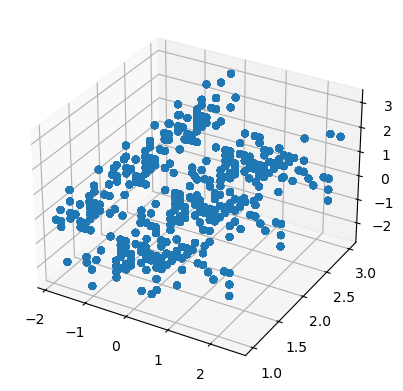

In [28]:
ax = plt.axes(projection='3d')
ax.scatter3D(x, y, z)
plt.show()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)#тестовая выборка не используется для подбора параметров, потому что обучение модели производится на тренировочном наборе данных, а тестовый должен использоваться только для тестирования с целью проверить работу модели с незнакомыми данными


In [19]:
knn = KNeighborsClassifier(n_neighbors=5)
#print(X_train.to_frame())
knn.fit(X_train, y_train)
predicted = knn.predict(X_test)
print(accuracy_score(y_test, predicted))

0.7555555555555555
